Preprocessing
Import Libraries & set Random Seeds

In [1]:
# read & manipulate data
import pandas as pd 
import numpy as np
import tensorflow as tf

# visualisations
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='notebook')
%matplotlib notebook

# misc
import random as rn

# load the dataset
#df = pd.read_csv('../input/creditcard.csv')
#df = pd.read_csv('C:\Project\Journal\dataset\psa_journal_home_A_unsupervise_train.csv')
#df = pd.read_csv('C:\Project\Journal\dataset\home_A_unsupervised_sim_combined_data.csv')
df = pd.read_csv("C:\\Users\\olufe\\projects\\Journal\\dataset\\HomeA_unsupervised_sim_combined_shuffled.csv")
#df = pd.read_csv('C:\\Users\\olufe\\projects\\Journal\\dataset\\psa_journal_home_A_unsupervise_train.csv')

In [2]:
df.head()

,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,...,M1371,M1372,M1373,M1374,M1375,M1376,M1377,M1378,M1379,Label
0,398,398,398,393,433,439,435,310,300,310,...,845,837,837,827,862,857,865,845,857,0
1,250,252,255,255,259,255,250,242,252,251,...,411,404,407,402,402,407,284,278,275,0
2,267,268,295,268,269,274,268,269,259,269,...,454,453,452,454,449,446,439,395,269,0
3,483,479,491,520,536,519,518,519,514,557,...,832,861,842,847,863,869,898,877,916,0
4,425,317,317,330,320,325,310,467,448,450,...,994,944,831,833,833,849,830,829,855,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35330 entries, 0 to 35329
Columns: 1381 entries, M0 to Label
dtypes: int64(1381)
memory usage: 372.2 MB


In [4]:
df.describe()

,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,...,M1371,M1372,M1373,M1374,M1375,M1376,M1377,M1378,M1379,Label
count,35330.000000,35330.000000,35330.000000,35330.000000,35330.000000,35330.000000,35330.000000,35330.000000,35330.000000,35330.000000,...,35330.000000,35330.000000,35330.000000,35330.000000,35330.000000,35330.000000,35330.000000,35330.000000,35330.000000,35330.000000
mean,493.445853,490.740900,488.690716,487.448995,485.836428,483.677639,481.395301,479.338777,478.021115,476.395952,...,802.993858,796.416162,789.347863,782.246476,774.837985,767.938494,761.047863,753.805491,747.009086,0.004076
std,553.404880,550.527152,547.300651,547.310178,546.423591,542.507339,537.740386,534.105647,533.456081,530.439327,...,741.935178,739.419217,735.856598,732.476456,727.776921,724.261875,720.843256,716.737133,713.061816,0.063713
min,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,...,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,0.000000
25%,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,...,370.000000,367.000000,363.000000,360.000000,356.000000,354.000000,352.000000,350.000000,348.000000,0.000000
50%,355.000000,354.000000,354.000000,353.000000,353.000000,352.000000,352.000000,351.000000,351.000000,351.000000,...,526.000000,518.000000,508.000000,499.000000,492.000000,485.000000,481.000000,477.000000,473.000000,0.000000
75%,459.000000,458.000000,458.000000,457.000000,457.000000,456.000000,456.000000,455.000000,455.000000,455.000000,...,940.000000,937.000000,932.000000,928.000000,923.000000,919.000000,914.000000,908.000000,903.000000,0.000000
max,6559.000000,6606.000000,6518.000000,6531.000000,6563.000000,6729.000000,6578.000000,6391.000000,6440.000000,6468.000000,...,6715.000000,6715.000000,6715.000000,6715.000000,6715.000000,6715.000000,6715.000000,6715.000000,6715.000000,1.000000


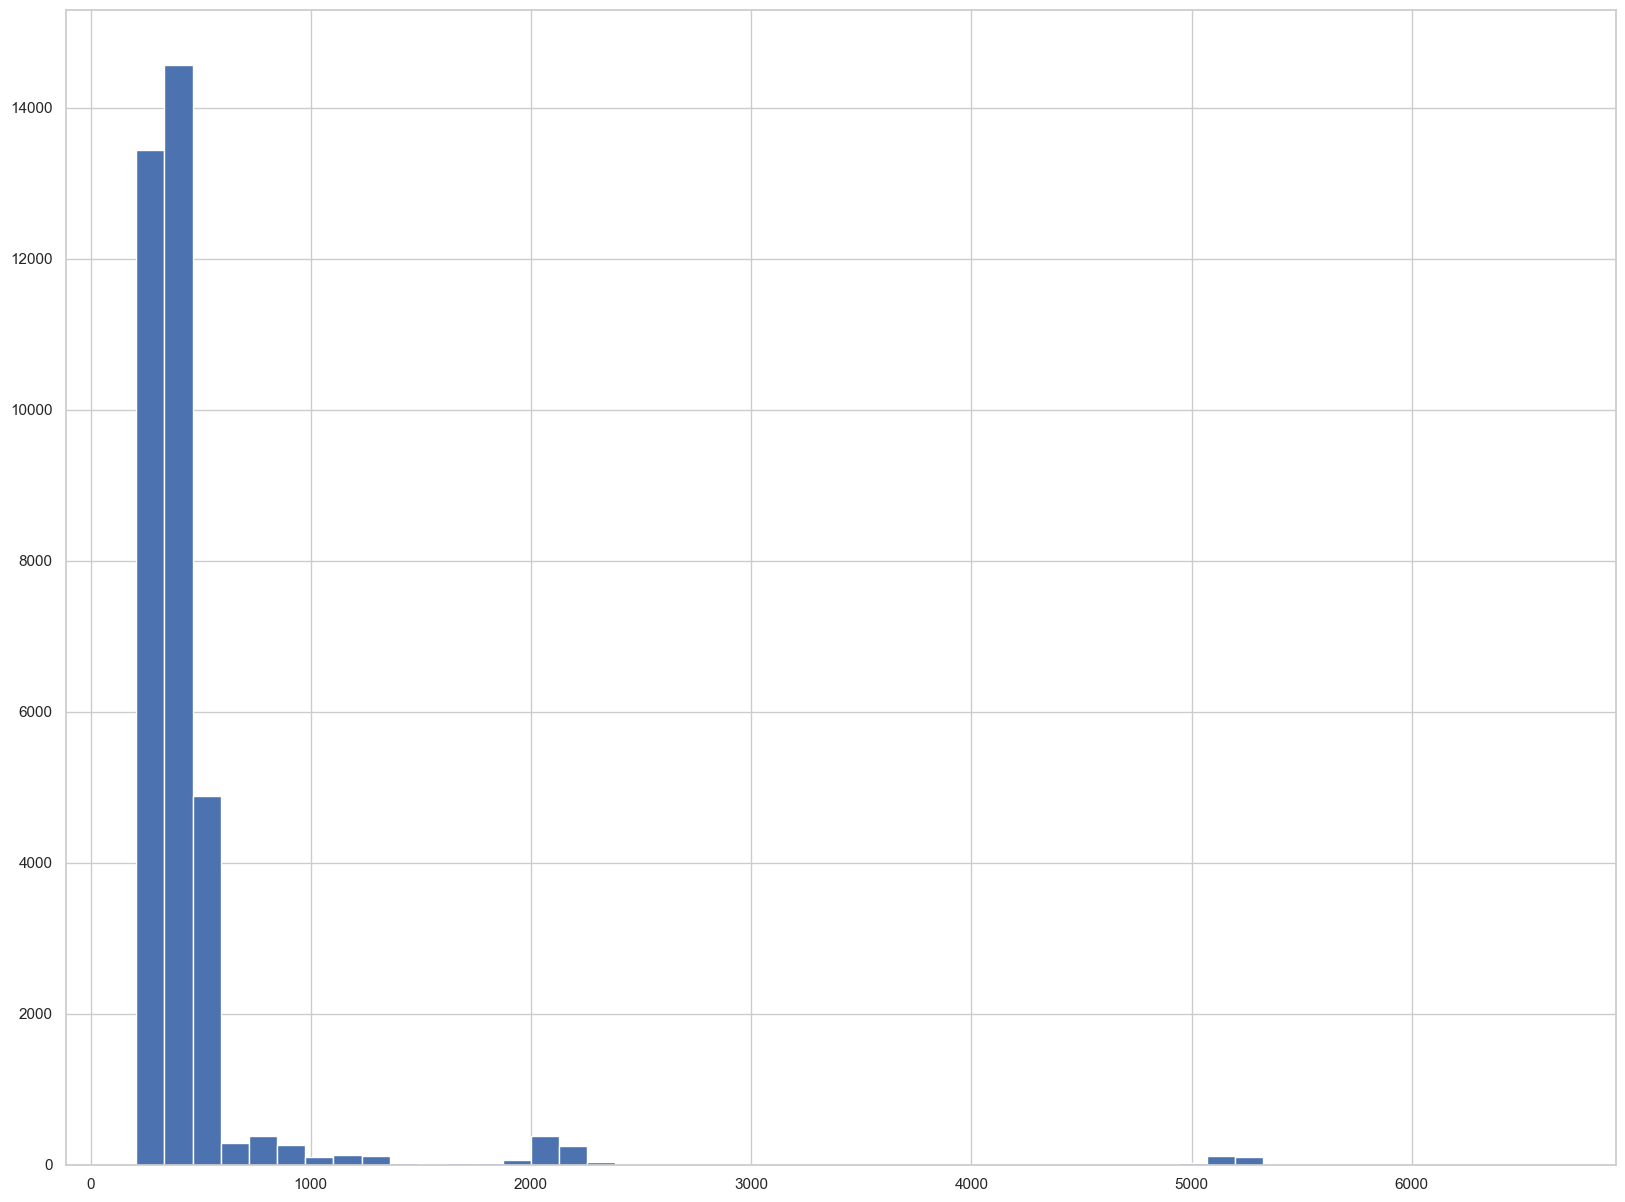

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
df['M12'].hist(bins=50, figsize=(20,15))
#df['Label'].hist(bins=50, figsize=(20,15))
plt.show()

In [6]:
df['Label'].value_counts()

0    35186
1      144
Name: Label, dtype: int64

In [ ]:
# manual parameters
RANDOM_SEED = 42
#TRAINING_SAMPLE = 200000
TRAINING_SAMPLE = 35000
VALIDATE_SIZE = 0.2

# setting random seeds for libraries to ensure reproducibility
#np.random.seed(RANDOM_SEED)
#rn.seed(RANDOM_SEED)
#
# Set the random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
rn.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

Visualising clusters with t-SNE

Undersampling the non-fraud¶
To keep the computation time low, let's feed t-SNE only a small subsample (undersampling the clean transactions).

In [ ]:
# manual parameter 
#RATIO_TO_THEFT = 20
RATIO_TO_THEFT = 5
# dropping redundant columns
#df = df.drop(['time', 'amount'], axis=1)

# splitting by class
theft = df[df.Label == 1]
benign = df[df.Label == 0]

# undersample clean transactions
benign_undersampled = benign.sample(
    int(len(theft) * RATIO_TO_THEFT),
    random_state=RANDOM_SEED
)

# concatenate with fraud transactions into a single dataframe
visualisation_initial = pd.concat([theft, benign_undersampled])
column_names = list(visualisation_initial.drop('Label', axis=1).columns)

# isolate features from labels 
features, labels = visualisation_initial.drop('Label', axis=1).values, \
                   visualisation_initial.Label.values

In [ ]:
print(f"""The non-theft dataset has been undersampled from {len(benign):,} to {len(benign_undersampled):,}.
This represents a ratio of {RATIO_TO_THEFT}:1 to theft.""")

t-SNE output

In [ ]:
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

def tsne_scatter(features, labels, dimensions=2, save_as='graph.png'):
    if dimensions not in (2, 3):
        raise ValueError('tsne_scatter can only plot in 2d or 3d (What are you? An alien that can visualise >3d?). Make sure the "dimensions" argument is in (2, 3)')

    # t-SNE dimensionality reduction
    features_embedded = TSNE(n_components=dimensions, random_state=RANDOM_SEED).fit_transform(features)
    
    # initialising the plot
    fig, ax = plt.subplots(figsize=(8,8))
    
    # counting dimensions
    if dimensions == 3: ax = fig.add_subplot(111, projection='3d')

    # plotting data
    ax.scatter(
        *zip(*features_embedded[np.where(labels==1)]),
        marker='o',
        color='r',
        s=2,
        alpha=0.7,
        label='Theft'
    )
    ax.scatter(
        *zip(*features_embedded[np.where(labels==0)]),
        marker='o',
        color='g',
        s=2,
        alpha=0.3,
        label='Benign'
    )

    # storing it to be displayed later
    plt.legend(loc='best')
    #plt.savefig(save_as);
    plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_combined_data_ran_sta_100.png',bbox_inches='tight')
    plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_combined_data_ran_sta_100.eps',bbox_inches='tight')
    plt.show;

In [ ]:
tsne_scatter(features, labels, dimensions=2, save_as='tsne_initial_2d.png')

In [ ]:
print(f"""Shape of the datasets:
    benign (rows, cols) = {benign.shape}
    theft (rows, cols) = {theft.shape}""")

In [ ]:
# shuffle our training set
benign = benign.sample(frac=1).reset_index(drop=True)

# training set: exlusively non-theft transactions
X_train = benign.iloc[:TRAINING_SAMPLE].drop('Label', axis=1)

# testing  set: the remaining non-theft + all the theft 
X_test = benign.iloc[TRAINING_SAMPLE:].append(theft).sample(frac=1)

In [ ]:
print(f"""Our testing set is composed as follows:

{X_test.Label.value_counts()}""")

In [ ]:
from sklearn.model_selection import train_test_split

# train // validate - no labels since they're all clean anyway
X_train, X_validate = train_test_split(X_train, 
                                       test_size=VALIDATE_SIZE, 
                                       random_state=RANDOM_SEED)

# manually splitting the labels from the test df
X_test, y_test = X_test.drop('Label', axis=1).values, X_test.Label.values

Summary

In [ ]:
print(f"""Shape of the datasets:
    training (rows, cols) = {X_train.shape}
    validate (rows, cols) = {X_validate.shape}
    holdout  (rows, cols) = {X_test.shape}""")

Normalising & Standardising

Building our pipeline

In [ ]:
from sklearn.preprocessing import Normalizer, MinMaxScaler
from sklearn.pipeline import Pipeline

# configure our pipeline
pipeline = Pipeline([('normalizer', Normalizer()),
                     ('scaler', MinMaxScaler())])

Fitting the pipeline

In [ ]:
# get normalization parameters by fitting to the training data
pipeline.fit(X_train);

In [ ]:
# transform the training and validation data with these parameters
X_train_transformed = pipeline.transform(X_train)
X_validate_transformed = pipeline.transform(X_validate)

In [ ]:
print(X_train_transformed)

In [ ]:
print(X_validate_transformed)

Before & After

In [ ]:
g = sns.PairGrid(X_train.iloc[:,:3].sample(600, random_state=RANDOM_SEED))
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Before:')
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.kdeplot);
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_B4_sns.kdeplot_ran_sta_100.png',bbox_inches='tight')
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_B4_sns.kdeplot_ran_sta_100.eps',bbox_inches='tight')

Applying transformations with acquired parameters

In [ ]:
g = sns.PairGrid(pd.DataFrame(X_train_transformed, columns=column_names).iloc[:,:3].sample(600, random_state=RANDOM_SEED))
plt.subplots_adjust(top=0.9)
g.fig.suptitle('After:')
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.kdeplot);
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_After_sns.kdeplot_ran_sta_100.png',bbox_inches='tight')
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_After_sns.kdeplot_ran_sta_100.eps',bbox_inches='tight')


Training the auto-encoder

Architecture of our model

In [ ]:
# data dimensions // hyperparameters 
input_dim = X_train_transformed.shape[1]
BATCH_SIZE = 128
EPOCHS = 100

# https://keras.io/layers/core/
autoencoder = tf.keras.models.Sequential([
    
    # deconstruct / encode
    tf.keras.layers.Dense(input_dim, activation='elu', input_shape=(input_dim, )), 
    tf.keras.layers.Dense(16, activation='elu'),
    tf.keras.layers.Dense(8, activation='elu'),
    tf.keras.layers.Dense(4, activation='elu'),
    tf.keras.layers.Dense(2, activation='elu'),
    
    # reconstruction / decode
    tf.keras.layers.Dense(4, activation='elu'),
    tf.keras.layers.Dense(8, activation='elu'),
    tf.keras.layers.Dense(16, activation='elu'),
    tf.keras.layers.Dense(input_dim, activation='elu')
    
])

# https://keras.io/api/models/model_training_apis/
autoencoder.compile(optimizer="adam", 
                    loss="mse",
                    metrics=["acc"])

# print an overview of our model
autoencoder.summary();

Callbacks

Continue as long as the model is reducing the training loss.
Save only the weights for the model with the lowest validation loss, though.
Get graphical insights with Tensorboard.

In [ ]:
from datetime import datetime

# current date and time
yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')

# new folder for a new run
log_subdir = f'{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(autoencoder.layers)}'

# define our early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=10,
    verbose=1, 
    mode='min',
    restore_best_weights=True
)

save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='autoencoder_best_weights.hdf5',
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)

tensorboard = tf.keras.callbacks.TensorBoard(
    f'logs/{log_subdir}',
    batch_size=BATCH_SIZE,
    update_freq='batch'
)

# callbacks argument only takes a list
#cb = [early_stop, save_model, tensorboard]
cb = [save_model, tensorboard]

Training

In [ ]:
history = autoencoder.fit(
    X_train_transformed, X_train_transformed,
    shuffle=True,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    validation_data=(X_validate_transformed, X_validate_transformed)
);

Reconstructions
We apply the transformation pipeline to our test set.
Then, we pass the data through the trained autoencoder.

In [ ]:
# transform the test set with the pipeline fitted to the training set
X_test_transformed = pipeline.transform(X_test)

# pass the transformed test set through the autoencoder to get the reconstructed result
reconstructions = autoencoder.predict(X_test_transformed)

Calculate the reconstruction loss for every transaction and draw a sample.

In [ ]:
# calculating the mean squared error reconstruction loss per row in the numpy array
mse = np.mean(np.power(X_test_transformed - reconstructions, 2), axis=1)

In [ ]:
benign = mse[y_test==0]
theft = mse[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(benign, bins=50, density=True, label="benign", alpha=.6, color="green")
ax.hist(theft, bins=50, density=True, label="theft", alpha=.6, color="red")

plt.title("(Normalized) Distribution of the Reconstruction Loss")
plt.legend()
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_(Normalized) Distribution of the Reconstruction Loss_ran_sta_100.png',bbox_inches='tight')
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_(Normalized) Distribution of the Reconstruction Loss_ran_sta_100.eps',bbox_inches='tight')
plt.show()

Very promising! Although some transactions seem to fool the autoencoder, the fraudulent transactions clearly have a distinguishing element in their data that sets them apart from clean ones.

## Setting a threshold for classification
### Unsupervised
Normally, in an unsupervised solution, this is where the story would end. We would set a threshold that limits the amount of false positives to a manageable degree, and captures the most anomalous data points.

Percentiles
We could set this threshold by taking the top x% of the dataset and considering it anomalous.

MAD
We could also use a modified Z-score using the Median Absolute Deviation to define outliers on our reconstruction data. Here is a good blog post on the topic by João Rodrigues, illustrating why this algorithm is more robust and scalable than the percentiles method.

In [ ]:
#THRESHOLD = 3
THRESHOLD = 2.0

def mad_score(points):
    """https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm """
    m = np.median(points)
    ad = np.abs(points - m)
    mad = np.median(ad)
    
    return 0.6745 * ad / mad

z_scores = mad_score(mse)
outliers = z_scores > THRESHOLD

In [ ]:
print(f"Detected {np.sum(outliers):,} outliers in a total of {np.size(z_scores):,} transactions [{np.sum(outliers)/np.size(z_scores):.2%}].")

Supervised¶
We know the labels, so we can verify our results.

Classification Matrix on MAD outliers¶
A closer look:

In [ ]:
from sklearn.metrics import (confusion_matrix, 
                             precision_recall_curve)

# get (mis)classification
cm = confusion_matrix(y_test, outliers)

# true/false positives/negatives
(tn, fp, 
 fn, tp) = cm.flatten()

In [ ]:
print(f"""The classifications using the MAD method with threshold={THRESHOLD} are as follows:
{cm}

% of transactions labeled as theft that were correct (precision): {tp}/({fp}+{tp}) = {tp/(fp+tp):.2%}
% of fraudulent transactions were caught succesfully (recall):    {tp}/({fn}+{tp}) = {tp/(fn+tp):.2%}""")

Asymmetric error cost
In the real world, we can expect different costs associated with reporting a false positive versus reporting a false negative. Missing a fraud case is likely to be much more costly than wrongly flagging a transaction as one. In another kernel, I discuss an approach to determining these costs for this dataset in depth.

Recall & Precision
Generally speaking, you will have to prioritise what you find more important. This dilemma is commonly called the "recall vs precision" trade-off. If you want to increase recall, adjust the MAD's Z-Score threshold downwards, if you want recover precision, increase it.

In [ ]:
benign = z_scores[y_test==0]
theft = z_scores[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(benign, bins=50, density=True, label="benign", alpha=.6, color="green")
ax.hist(theft, bins=50, density=True, label="theft", alpha=.6, color="red")

plt.title("Distribution of the modified z-scores")
plt.legend()
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_Distribution of the modified z-scores_ran_sta_100.png',bbox_inches='tight')
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_Distribution of the modified z-scores_ran_sta_100.eps',bbox_inches='tight')
plt.show()

Latent Space
It is always interesting to look at the compressed representation our neural network devised.

Encoder
Let's build the encoder that gets us to the bottleneck. We take the layers from our autoencoder.

In [ ]:
encoder = tf.keras.models.Sequential(autoencoder.layers[:5])
encoder.summary()

Undersampling
Consistent with the previous t-sne visualisation, let's undersample the benign transactions.

In [ ]:
# taking all the theft, undersampling benign
theft = X_test_transformed[y_test==1]
benign = X_test_transformed[y_test==0][:len(theft) * RATIO_TO_THEFT, ]

# combining arrays & building labels
features = np.append(theft, benign, axis=0)
labels = np.append(np.ones(len(theft)),
                   np.zeros(len(benign)))

# getting latent space representation
latent_representation = encoder.predict(features)

print(f'Benign transactions downsampled from {len(X_test_transformed[y_test==0]):,} to {len(benign):,}.')
print('Shape of latent representation:', latent_representation.shape)

Visualising the Latent Space

In [ ]:
X = latent_representation[:,0]
y = latent_representation[:,1]

# plotting
plt.subplots(figsize=(8, 8))
plt.scatter(X[labels==0], y[labels==0], s=1, c='g', alpha=0.3, label='Benign')
plt.scatter(X[labels==1], y[labels==1], s=2, c='r', alpha=0.7, label='Theft')

# labeling
plt.legend(loc='best')
plt.title('Latent Space Representation')

# saving & displaying
plt.savefig('latent_representation_2d');
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_latent_representation_2d_ran_sta_100.png',bbox_inches='tight')
plt.savefig('C:\Project\Journal\Results\home_A_unsupervised_sim_latent_representation_2d_ran_sta_100.eps',bbox_inches='tight')
plt.show()

Although there is no perfectly distinct cluster, most of the fradulent transactions appear to be neatly grouped together. This is in line with the hope/idea that both classes would occupy distinct areas in latent space, due to the encoder's weights not being calibrated to cope with fraudulent transactions.

Conclusion
We could already tell from our misclassifications that the network was not able to generalize perfectly. However, we must not forget that our model was trained never having seen a single fraud case! In that regard, its performance is decent. It illustrates the power of autoencoders as anomaly detection tools.

To improve its performance, perhaps we need to:

improve the model architecture
diversify the training data more, with a broader sample of clean transactions
augment the data with different, additional features - the data itself might not be good enough to distinguish between classes perfectly (i.e. fraudsters are disguising themselves well enough to always go undetected using these data points, no matter the algorithm).